# Dynamic Incentive Optimizer — DIO-KFC

**Applying Duolingo's Streak Psychology to KFC's Chicken Miles × Uplift Modeling (T-Learner)**

---

## このノートブックで行うこと

| Step | 内容 | モジュール |
|------|------|----------|
| 1 | 合成データ生成（10K顧客×4セグメント×段階的介入フロー） | `generate_data.py` |
| 2 | T-Learner学習（Model A + Model B）+ Qini曲線 + SHAP | `train_uplift.py` |
| 3 | CATEベース期待利益最大化 + 鉄板層自動カット | `optimize_incentive.py` |
| 4 | 増分ROI・無駄削減率・CATE分布 | `evaluate_roi.py` |
| 5 | 全図表生成（優先度A×2 + 優先度B×2） | `visualize.py` |

📝 **ビジネス背景・CRM戦略は [NOTE記事](https://note.com/tsunoda_data/n/n94bdcf5478db?sub_rt=share_pw) をご覧ください。**

---

## 0. 環境セットアップ

In [9]:
!git clone https://github.com/tsunoda-data/dynamic-incentive-optimizer.git
%cd dynamic-incentive-optimizer

import os
os.makedirs('outputs', exist_ok=True)

Cloning into 'dynamic-incentive-optimizer'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 30.97 KiB | 30.97 MiB/s, done.
/content/dynamic-incentive-optimizer


In [10]:
!pip install -q -r requirements.txt

In [11]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install japanize-matplotlib
import japanize_matplotlib
from IPython.display import display, Image
import glob, os
print('✅ 環境セットアップ完了')

✅ 環境セットアップ完了


---
## 1. 合成データ生成

### 設計の核心: 段階的介入フロー

```
全顧客 (10,000人)
    ↓ サイクル崩れ検知
    ↓ 完全デジタル非金銭インセンティブ提示
        ├─ 反応あり (30%): is_churn=0 → コストゼロで防衛成功
        └─ 反応なし (70%): T-Learner対象
               ├─ Control群 (50%): discount=0.00
               └─ Treatment群 (50%): discount=0.01〜0.30
```

In [12]:
from generate_data import generate_data, save_data, print_summary

df = generate_data()
save_data(df)
print_summary(df)

✅ データ保存完了: /content/dynamic-incentive-optimizer/data/customers.csv  (10,000件)

📊 合成データ生成サマリー

  総顧客数:              10,000人
  非金銭インセンティブ反応: 3,000人 (30.0%)
    └ コントロール群:      3,557人 (35.6%)
    └ トリートメント群:    3,443人 (34.4%)

  全体離脱率:            18.2%
  非反応者の離脱率:       26.0%

【ランク別分布】
               顧客数   離脱率    平均客単価  平均90日マイル
current_rank                               
ゴールド           997  0.13  1525.49    169.93
シルバー          2067  0.15  1550.95     85.35
ブロンズ          2478  0.20  1529.45     25.16
プラチナ           500  0.12  1595.99    343.52
レギュラー         3958  0.21  1536.01     14.56

【セグメント別分布】
          顧客数   離脱率    平均客単価  平均来店周期
segment                             
シニア      1954  0.21   946.97   44.66
ファミリー    3542  0.18  2641.73   17.46
単身ヘビー    1983  0.17  1154.37   10.56
学生       2521  0.16   752.76   32.96



In [13]:
display(df.head(10))

,user_id,lifetime_total_mileage,current_rank,current_rank_encoded,current_90d_mileage,visit_momentum,avg_spend_recent,personal_cycle_days,days_until_next_cycle,past_discount_exposure_count,wishlist_items_count,mileage_defense_ratio,reacted_to_non_financial_incentive,dynamic_treatment_flag,discount_rate_offered,optimal_send_hour,segment,price_elasticity,is_churn
0,U00000,8170,シルバー,2,46,1.34,787,44,-2,10,4,0.460,0,1,0.20,14,学生,0.9,0
1,U00001,13017,シルバー,2,44,1.46,915,11,21,6,4,0.440,1,0,0.00,19,単身ヘビー,0.6,0
2,U00002,4252,レギュラー,0,23,1.41,1104,38,-9,4,0,999.000,0,0,0.00,16,シニア,0.3,0
3,U00003,1893,レギュラー,0,4,0.50,554,22,42,2,6,999.000,0,1,0.16,11,学生,0.9,0
4,U00004,4521,レギュラー,0,9,1.78,2586,19,11,1,3,999.000,1,0,0.00,11,ファミリー,0.4,0
5,U00005,3089,レギュラー,0,4,1.16,708,49,53,3,0,999.000,0,1,0.12,12,シニア,0.3,0
6,U00006,3319,レギュラー,0,13,1.25,731,34,-3,9,0,999.000,0,0,0.00,8,学生,0.9,0
7,U00007,1714,プラチナ,4,322,0.46,757,21,13,4,6,0.805,0,0,0.00,14,学生,0.9,1
8,U00008,3756,レギュラー,0,9,0.42,2384,20,32,10,7,999.000,0,0,0.00,9,ファミリー,0.4,1
9,U00009,267,レギュラー,0,24,0.58,1181,12,9,9,4,999.000,0,1,0.05,8,単身ヘビー,0.6,0


---
## 2. Stage 1: Uplift Modeling (T-Learner)

### なぜT-Learnerか？

$$\text{CATE}_i(d) = P_A(\text{churn}_i) - P_B(\text{churn}_i \mid d)$$

- **Model A** (Control): 自然離脱確率 $P_A$ を推定
- **Model B** (Treatment): 介入時離脱確率 $P_B(d)$ を推定  
- 差分のCATEが「割引の純粋な増分効果」を表し、**最適化の中核**に据えられる

In [14]:
from train_uplift import run_training_pipeline

model_a, model_b, df_cate, metrics_train, qini = run_training_pipeline(df)


🤖 Stage 1: Uplift Modeling (T-Learner)
  T-Learner 学習対象: 7,000人 (全体の 70.0%)
  Control群:   3,557人
  Treatment群: 3,443人

  [Model A — Control] 学習中...
  [Model A (Control)] AUC-ROC: 0.6161 | PR-AUC: 0.3725 | Brier: 0.2026

  [Model B — Treatment] 学習中...
  [Model B (Treatment)] AUC-ROC: 0.6653 | PR-AUC: 0.3240 | Brier: 0.1643

  Qini曲線を計算中...
  Qini係数: -0.3393

  Uplift by Decile:
 Decile   N  N_Treatment  N_Control    Uplift
      1 700          603         97 -0.701527
      2 700          556        144 -0.531475
      3 700          516        184 -0.339821
      4 700          416        284 -0.255620
      5 700          341        359 -0.086906
      6 700          285        415 -0.033228
      7 700          225        475  0.158830
      8 700          194        506  0.268428
      9 700          148        552  0.454025
     10 700          159        541  0.694533

  SHAP分析中...
    保存: /content/dynamic-incentive-optimizer/outputs/shap_summary_model_a.png
    保存: /content/dyna

In [15]:
# Uplift by Decile テーブル
print(f'\nQini係数: {qini["qini_coef"]:.4f}')
display(metrics_train['uplift_by_decile'])


Qini係数: -0.3393


,Decile,N,N_Treatment,N_Control,Uplift
0,1,700,603,97,-0.701527
1,2,700,556,144,-0.531475
2,3,700,516,184,-0.339821
3,4,700,416,284,-0.255620
4,5,700,341,359,-0.086906
5,6,700,285,415,-0.033228
6,7,700,225,475,0.158830
7,8,700,194,506,0.268428
8,9,700,148,552,0.454025
9,10,700,159,541,0.694533


In [18]:
import matplotlib.pyplot as plt

# Qini曲線プロット
plt.figure(figsize=(10, 6))
plt.plot(qini['proportions'], qini['uplifts'], label='Qini Curve')
plt.plot(qini['proportions'], qini['random_line'], linestyle='--', color='gray', label='Random Line')
plt.title(f'Qini Curve (Qini coefficient: {qini["qini_coef"]:.4f})')
plt.xlabel('Proportion of Population (Sorted by CATE)')
plt.ylabel('Cumulative Uplift')
plt.grid(True)
plt.legend()
plt.savefig('outputs/qini_curve.png')
plt.close() # プロットを表示せずに保存のみ行う
print('✅ Qini曲線を保存しました: outputs/qini_curve.png')

✅ Qini曲線を保存しました: outputs/qini_curve.png


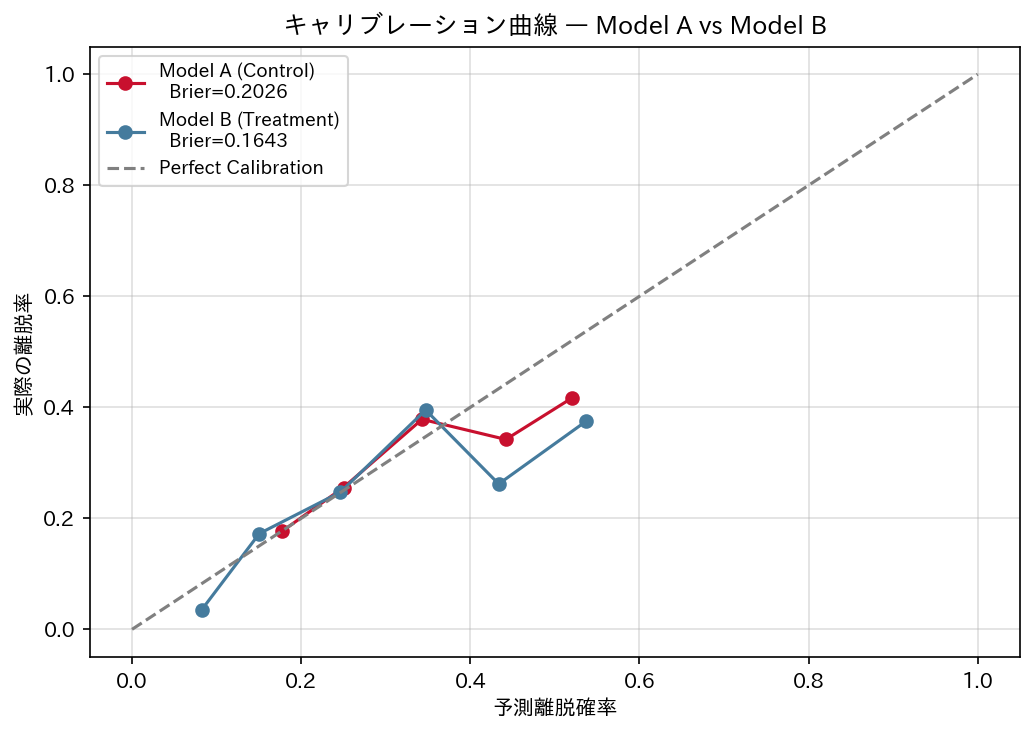

In [16]:
# キャリブレーション曲線
display(Image(filename='outputs/calibration_curves.png', width=650))

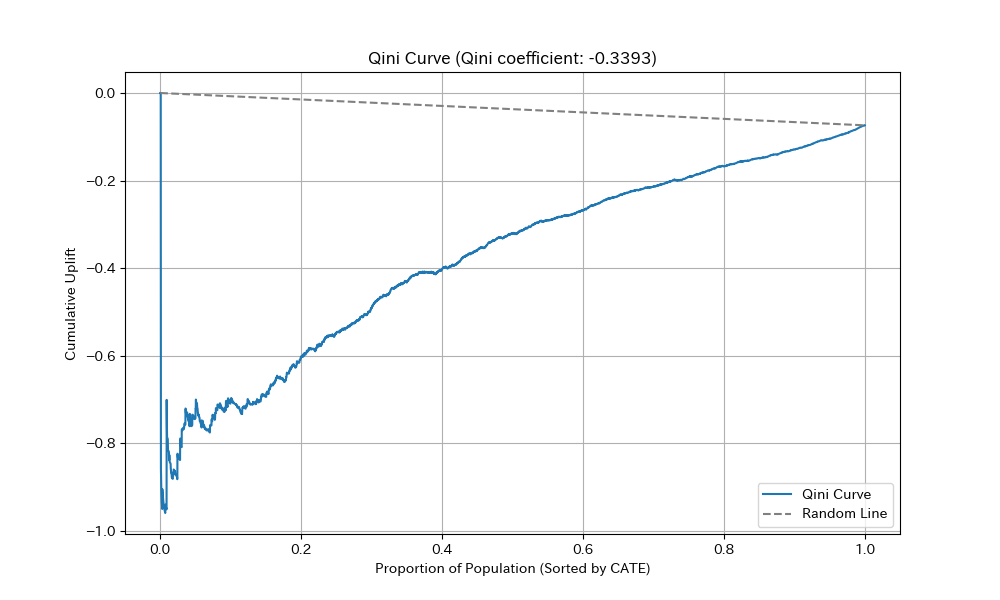

In [19]:
# Qini曲線
display(Image(filename='outputs/qini_curve.png', width=700))

--- Model A (Control) ---


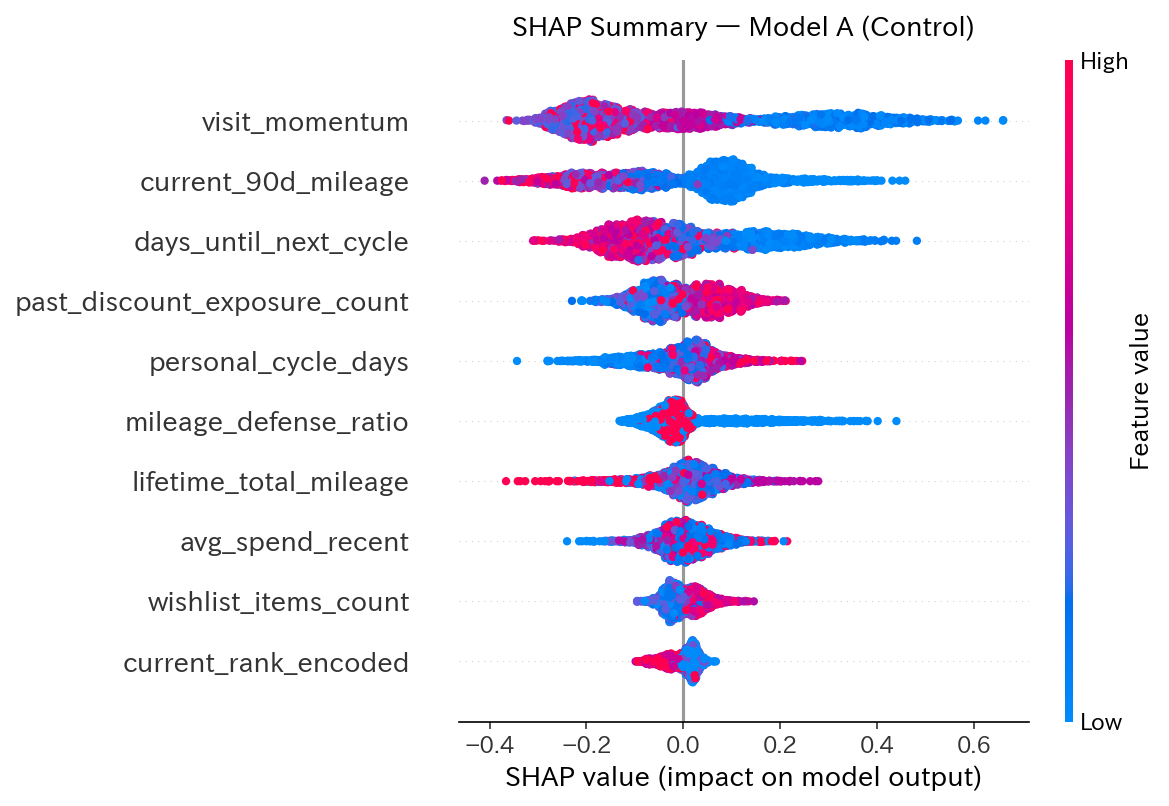

--- Model B (Treatment) ---


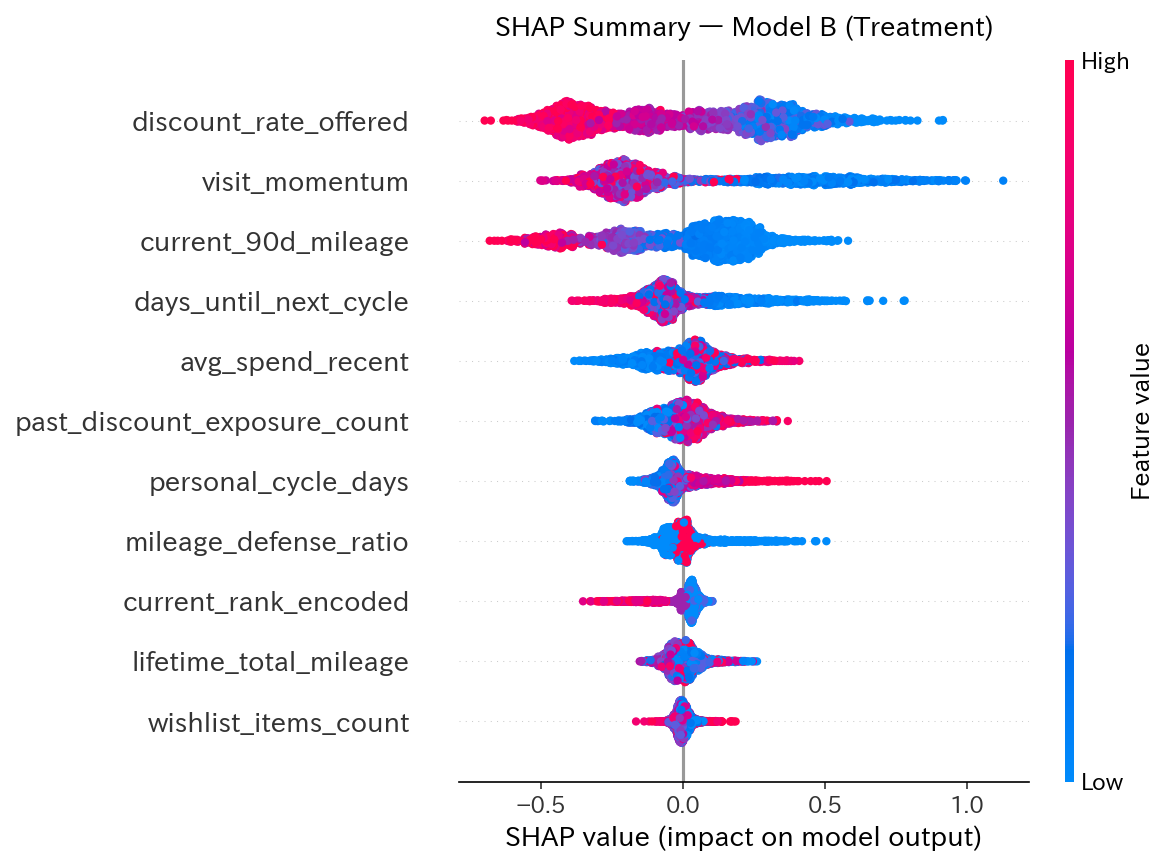

In [20]:
# SHAP Summary: Model A vs Model B 対比
print('--- Model A (Control) ---')
display(Image(filename='outputs/shap_summary_model_a.png', width=700))
print('--- Model B (Treatment) ---')
display(Image(filename='outputs/shap_summary_model_b.png', width=700))


--- shap_waterfall_B_中程度説得層.png ---


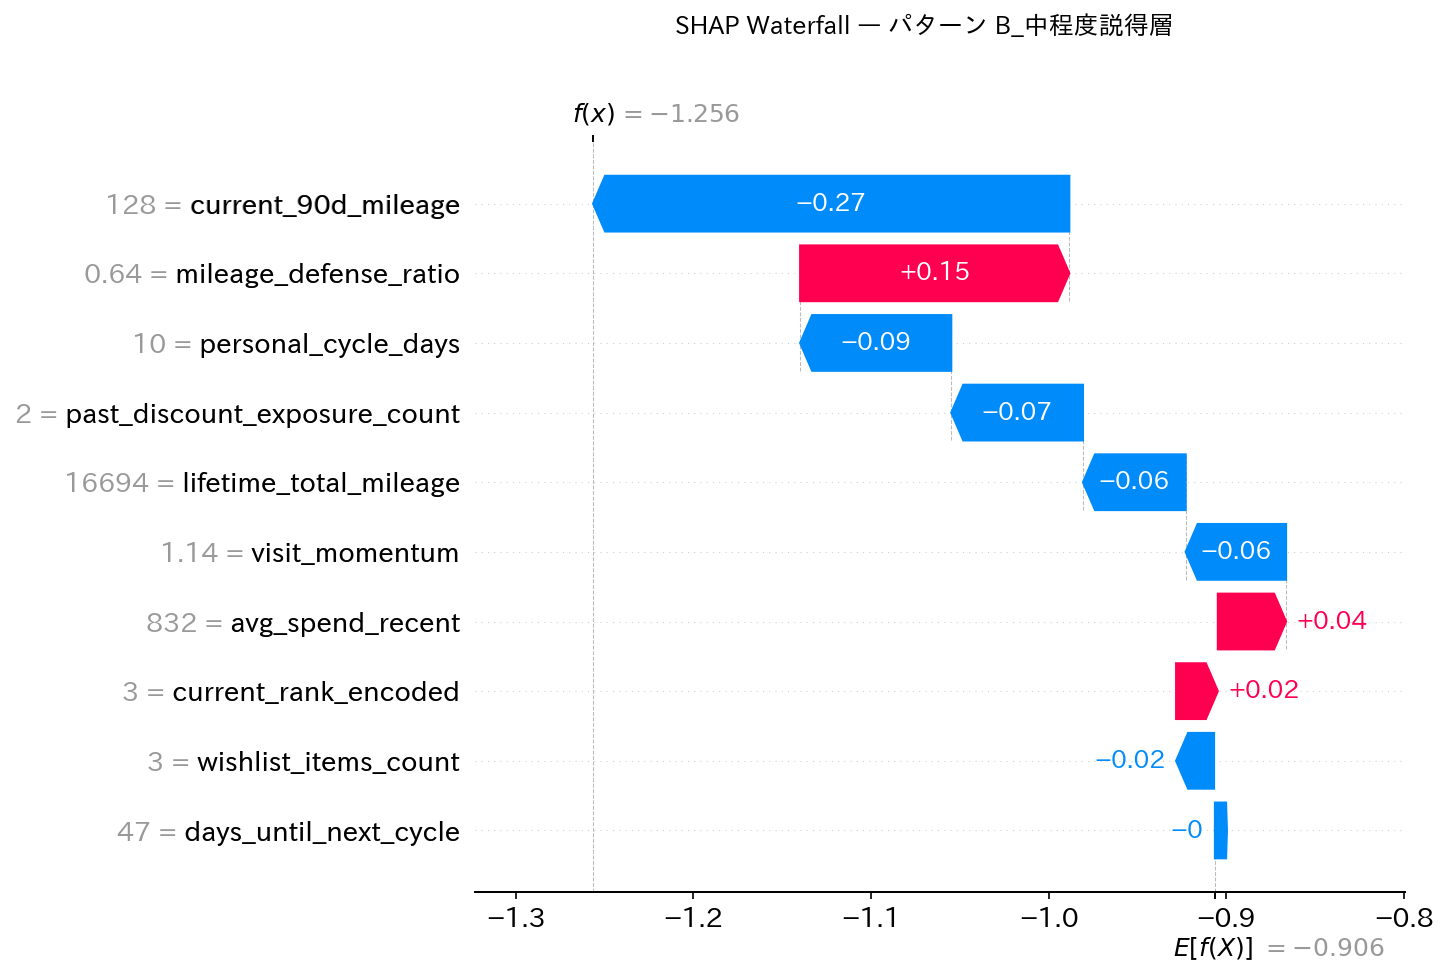


--- shap_waterfall_C_高弾力説得層.png ---


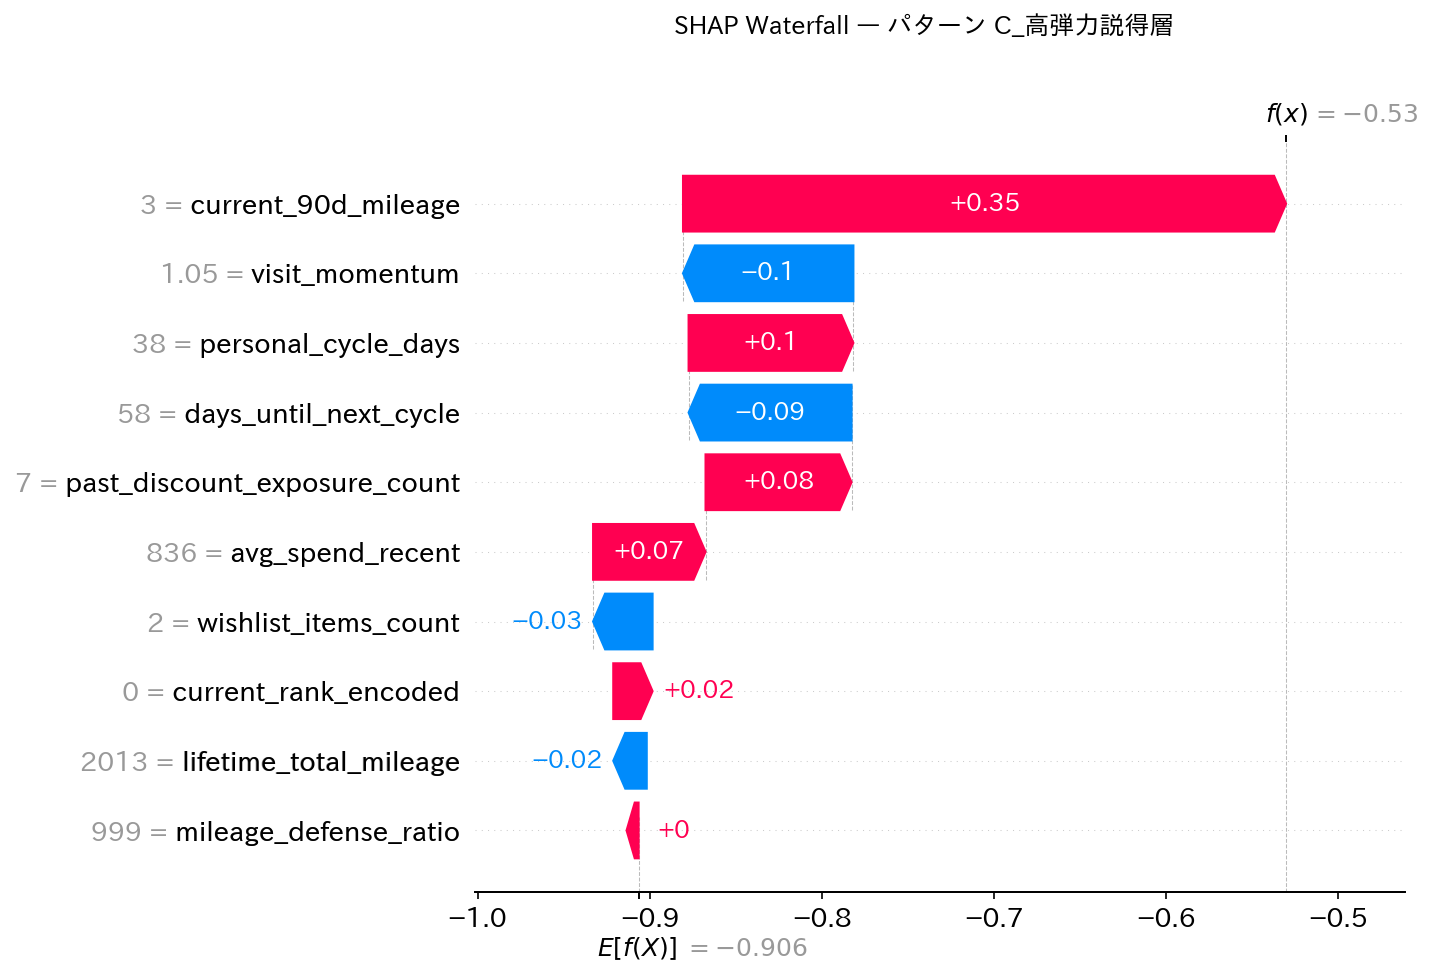

In [21]:
# SHAP Waterfall: 3パターン
for path in sorted(glob.glob('outputs/shap_waterfall_*.png')):
    print(f'\n--- {os.path.basename(path)} ---')
    display(Image(filename=path, width=700))

---
## 3. Stage 2: CATEベース期待利益最大化

### 目的関数

$$\text{Profit}_i(d) = \underbrace{\text{CATE}_i(d) \times V_i \times (1-C)}_{\text{増分粗利}} - \underbrace{d \times V_i \times (1-P_B)}_{\text{割引コスト}} - \underbrace{\lambda \cdot V_i \cdot d^2 \cdot E_i}_{\text{ペナルティ}}$$

**T-Learner必然性のポイント:**  
CATEがゼロの鉄板層では第1項もゼロ → 割引コストが必ず利益を上回り → $d^* = 0$ が自動選択

In [22]:
from optimize_incentive import run_optimization_pipeline

df_result = run_optimization_pipeline(model_a, model_b, df_cate)


⚙️  Stage 2: CATEベース期待利益最大化
  ペナルティ強度 λ = 1.5
  割引率グリッド: 0.00 〜 0.30 (31点)
  最適化対象: 7,000人
  Model B グリッド予測中...
  鉄板層 (P_A < 0.1): 0人 (0.0%) → 割引ゼロに強制

【最適化結果サマリー】
  平均最適割引率:      1.6%
  一律20%との利益差:   4,602,809円 (合計)
  割引ゼロ(d*=0):     3,852人 (55.0%)

  顧客タイプ分布:
    天邪鬼層 (Sleeping Dogs): 2,459人 (35.1%)
    説得層 (Persuadables): 2,419人 (34.6%)
    鉄板層 (Sure Things): 2,122人 (30.3%)

✅ Stage 2 完了



In [23]:
# 最適化結果の先頭確認
cols = ['user_id', 'current_rank', 'segment', 'avg_spend_recent',
        'p_natural_churn', 'cate_at_optimal', 'optimal_discount',
        'optimal_profit', 'uniform_profit', 'profit_improvement',
        'customer_type', 'is_iron_plate']
display(
    df_result[df_result['reacted_to_non_financial_incentive'] == 0][cols].head(15)
)

,user_id,current_rank,segment,avg_spend_recent,p_natural_churn,cate_at_optimal,optimal_discount,optimal_profit,uniform_profit,profit_improvement,customer_type,is_iron_plate
0,U00000,シルバー,学生,787,0.480319,0.1856,0.00,87.6,-464.1,551.8,説得層 (Persuadables),False
2,U00002,レギュラー,シニア,1104,0.294612,-0.0387,0.00,-25.6,-393.0,367.4,天邪鬼層 (Sleeping Dogs),False
3,U00003,レギュラー,学生,554,0.342749,0.0173,0.04,-11.9,-125.6,113.8,鉄板層 (Sure Things),False
5,U00005,レギュラー,シニア,708,0.300519,0.0132,0.00,5.6,-181.3,187.0,鉄板層 (Sure Things),False
6,U00006,レギュラー,学生,731,0.387169,0.0878,0.00,38.5,-430.4,468.9,説得層 (Persuadables),False
7,U00007,プラチナ,学生,757,0.359195,0.1333,0.04,29.8,-225.6,255.4,説得層 (Persuadables),False
8,U00008,レギュラー,ファミリー,2384,0.483299,0.1149,0.03,87.0,-1557.6,1644.6,説得層 (Persuadables),False
9,U00009,レギュラー,単身ヘビー,1181,0.298282,-0.0222,0.03,-54.2,-801.9,747.7,天邪鬼層 (Sleeping Dogs),False
10,U00010,シルバー,単身ヘビー,1192,0.183060,-0.0835,0.03,-100.4,-807.8,707.4,天邪鬼層 (Sleeping Dogs),False
13,U00013,レギュラー,シニア,1094,0.382456,0.1288,0.00,84.5,-368.1,452.6,説得層 (Persuadables),False


---
## 4. ビジネス評価 & 可視化

In [24]:
from evaluate_roi import run_evaluation_pipeline

metrics = run_evaluation_pipeline(df_result, qini)


📈 ビジネス評価指標

  ① 非金銭防衛成功率:       30.0%  (ベンチマーク: 30%)
  ② 鉄板層比率:             0.0% (0人)
  ③ 無駄なインセンティブ削減率: 0.0%
  ④ 一律20%の総期待利益:  -4,670,840円
  ⑤ AI最適化の総期待利益:   -68,031円
  ⑥ 増分利益 (Incr. ROI):  +4,602,810円 (98.5%改善)

  【顧客タイプ別統計】
                       顧客数  平均CATE  平均最適割引率  平均期待利益
customer_type                                      
天邪鬼層 (Sleeping Dogs)  2459  -0.090    0.017 -99.160
説得層 (Persuadables)    2419   0.105    0.015  78.010
鉄板層 (Sure Things)     2122   0.016    0.015  -6.081

  【ランク別統計】
               顧客数 鉄板層比率  平均最適割引率  平均CATE   AI利益合計     一律利益合計       利益増分
current_rank                                                            
ゴールド           710   0.0    0.012   0.051  19876.4  -467784.4   487661.0
シルバー          1462   0.0    0.016   0.005 -18864.7 -1000546.1   981681.0
ブロンズ          1729   0.0    0.017   0.009 -23695.3 -1160254.2  1136559.0
プラチナ           344   0.0    0.011   0.060  14378.2  -226660.8   241039.0
レギュラー         2755   0.0    0.017  -0.006 -59725.3 -1815595.0 

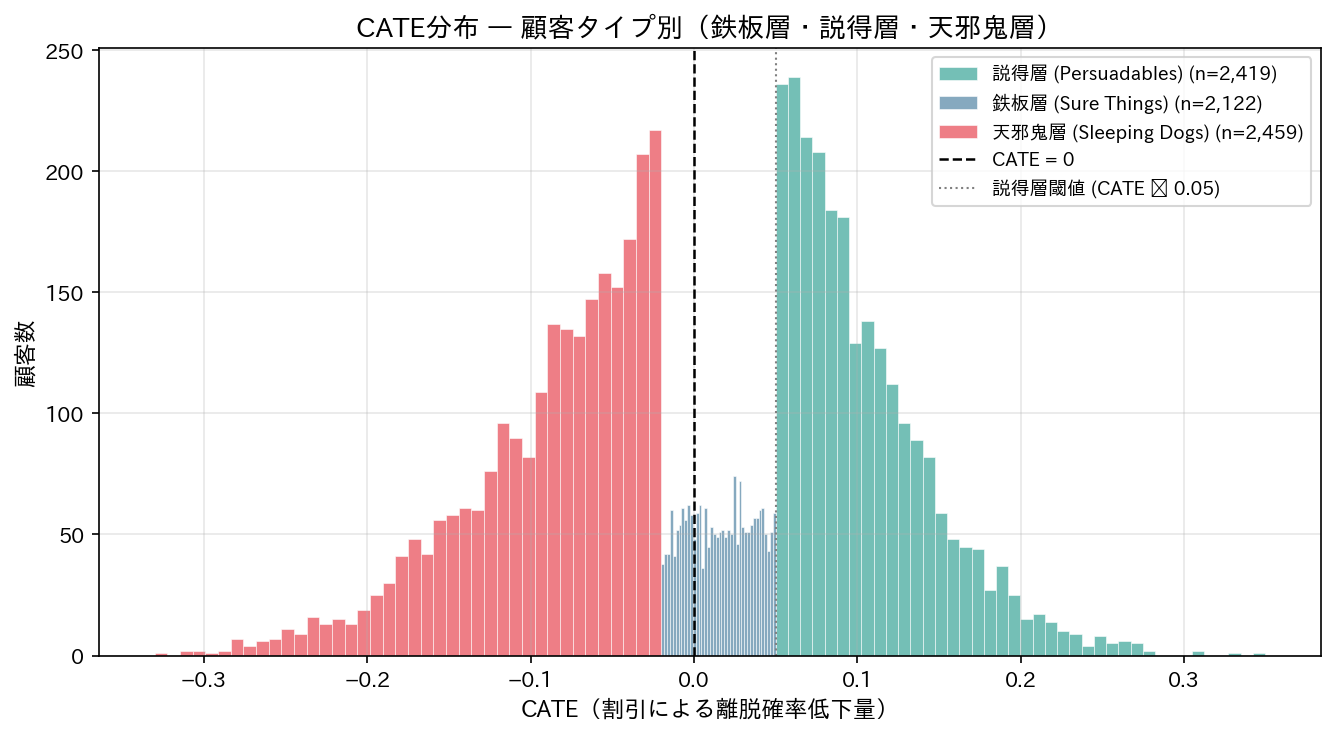

In [25]:
# CATE分布（顧客タイプ別）
display(Image(filename='outputs/cate_distribution.png', width=750))

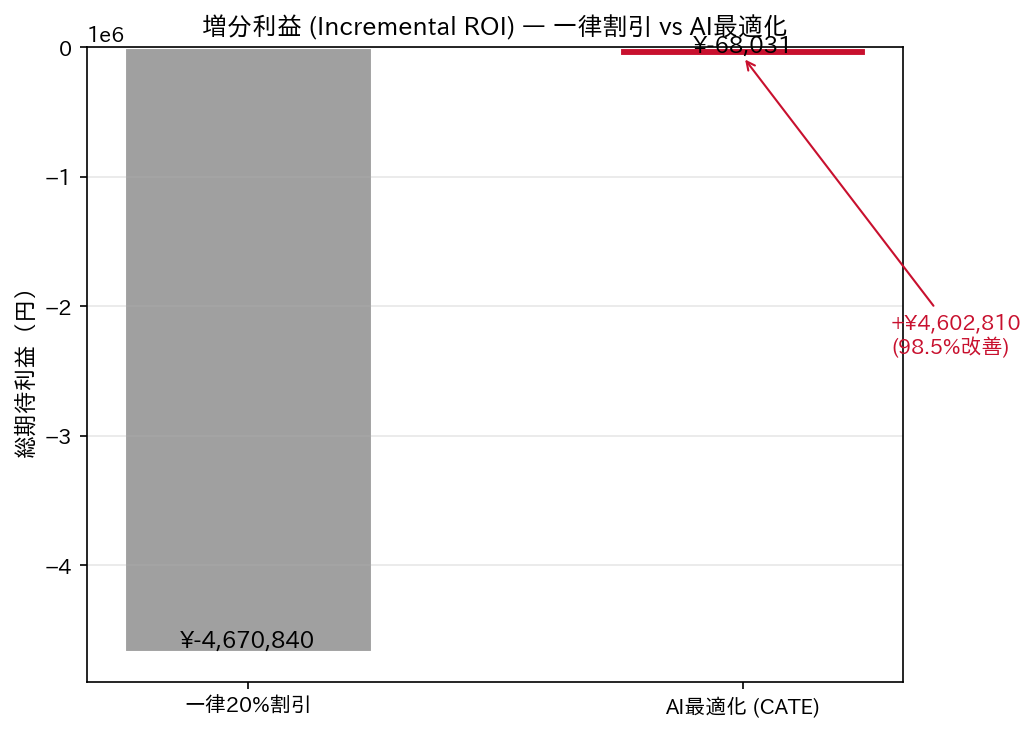

In [26]:
# ROI比較
display(Image(filename='outputs/roi_comparison.png', width=600))

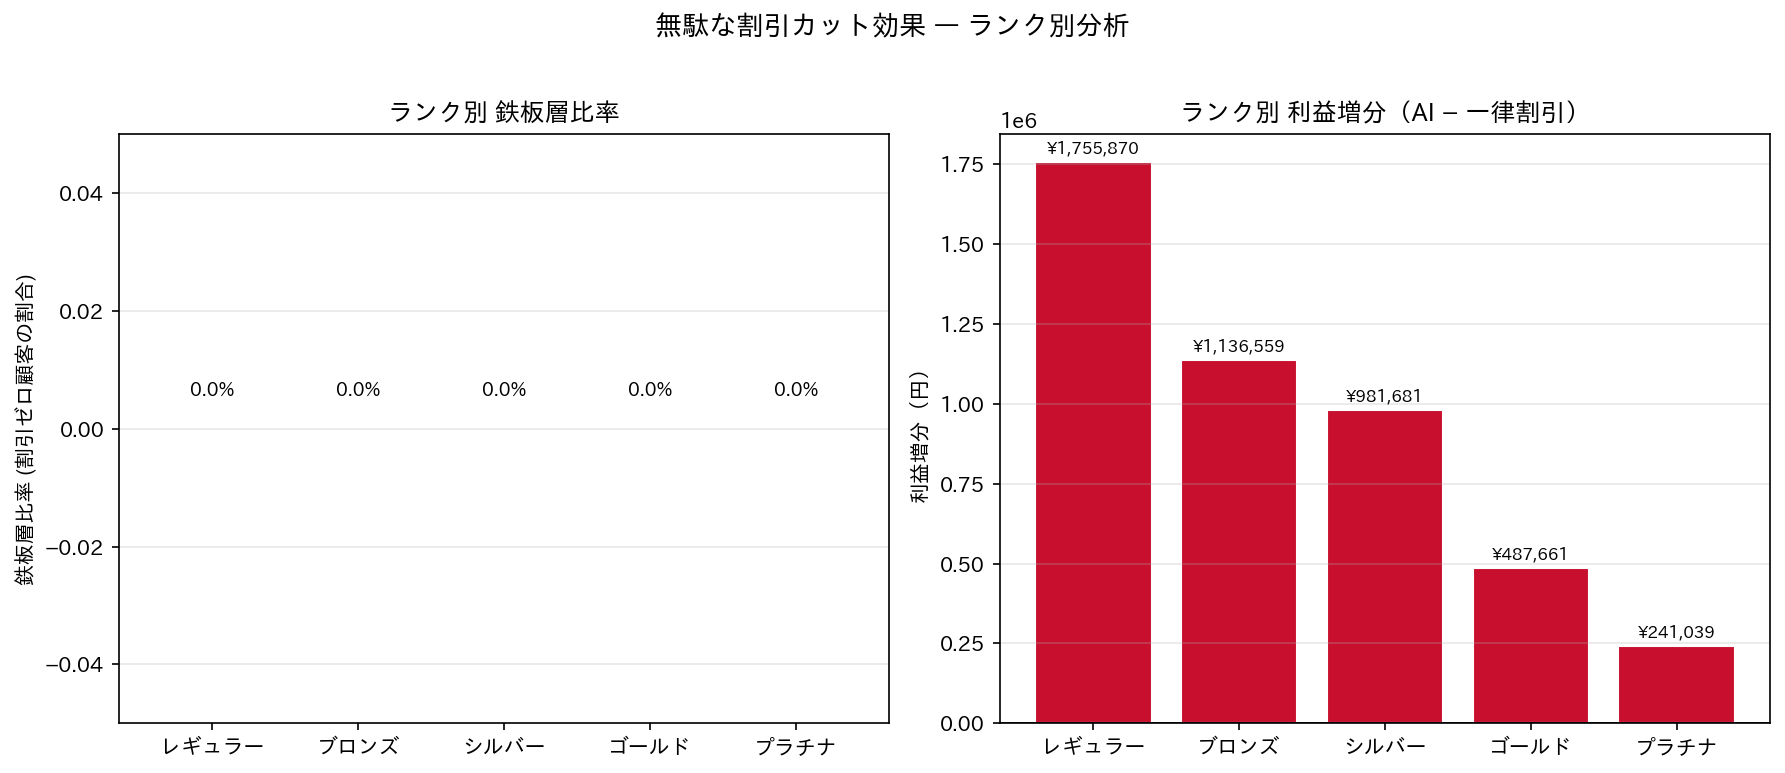

In [27]:
# 無駄な割引カット効果
display(Image(filename='outputs/waste_reduction.png', width=850))

---
## 5. 追加可視化（優先度A: 利益カーブ & 優先度B: 感度分析）

In [28]:
from optimize_incentive import sensitivity_analysis
from visualize import run_visualization_pipeline

# λ感度分析（時間がかかる場合はコメントアウト可）
sensitivity_df = sensitivity_analysis(model_a, model_b, df_cate)

# 全図表生成
run_visualization_pipeline(model_a, model_b, df_cate, df_result, sensitivity_df)


📊 感度分析: ペナルティ強度 λ の影響

⚙️  Stage 2: CATEベース期待利益最大化
  ペナルティ強度 λ = 0.5
  割引率グリッド: 0.00 〜 0.30 (31点)
  最適化対象: 7,000人
  Model B グリッド予測中...
  鉄板層 (P_A < 0.1): 0人 (0.0%) → 割引ゼロに強制

【最適化結果サマリー】
  平均最適割引率:      2.1%
  一律20%との利益差:   2,263,796円 (合計)
  割引ゼロ(d*=0):     3,236人 (46.2%)

  顧客タイプ分布:
    説得層 (Persuadables): 2,608人 (37.3%)
    天邪鬼層 (Sleeping Dogs): 2,250人 (32.1%)
    鉄板層 (Sure Things): 2,142人 (30.6%)

✅ Stage 2 完了

  λ=0.5: 平均割引率=2.1% | 合計利益=-39,852円 | ゼロ割引=46.2%

⚙️  Stage 2: CATEベース期待利益最大化
  ペナルティ強度 λ = 1.0
  割引率グリッド: 0.00 〜 0.30 (31点)
  最適化対象: 7,000人
  Model B グリッド予測中...
  鉄板層 (P_A < 0.1): 0人 (0.0%) → 割引ゼロに強制

【最適化結果サマリー】
  平均最適割引率:      1.8%
  一律20%との利益差:   3,431,737円 (合計)
  割引ゼロ(d*=0):     3,539人 (50.6%)

  顧客タイプ分布:
    説得層 (Persuadables): 2,493人 (35.6%)
    天邪鬼層 (Sleeping Dogs): 2,375人 (33.9%)
    鉄板層 (Sure Things): 2,132人 (30.5%)

✅ Stage 2 完了

  λ=1.0: 平均割引率=1.8% | 合計利益=-55,507円 | ゼロ割引=50.6%

⚙️  Stage 2: CATEベース期待利益最大化
  ペナルティ強度 λ = 1.5
  割引率グリッド: 0.00 〜 0.30 (31点)
  最適化対象: 7,

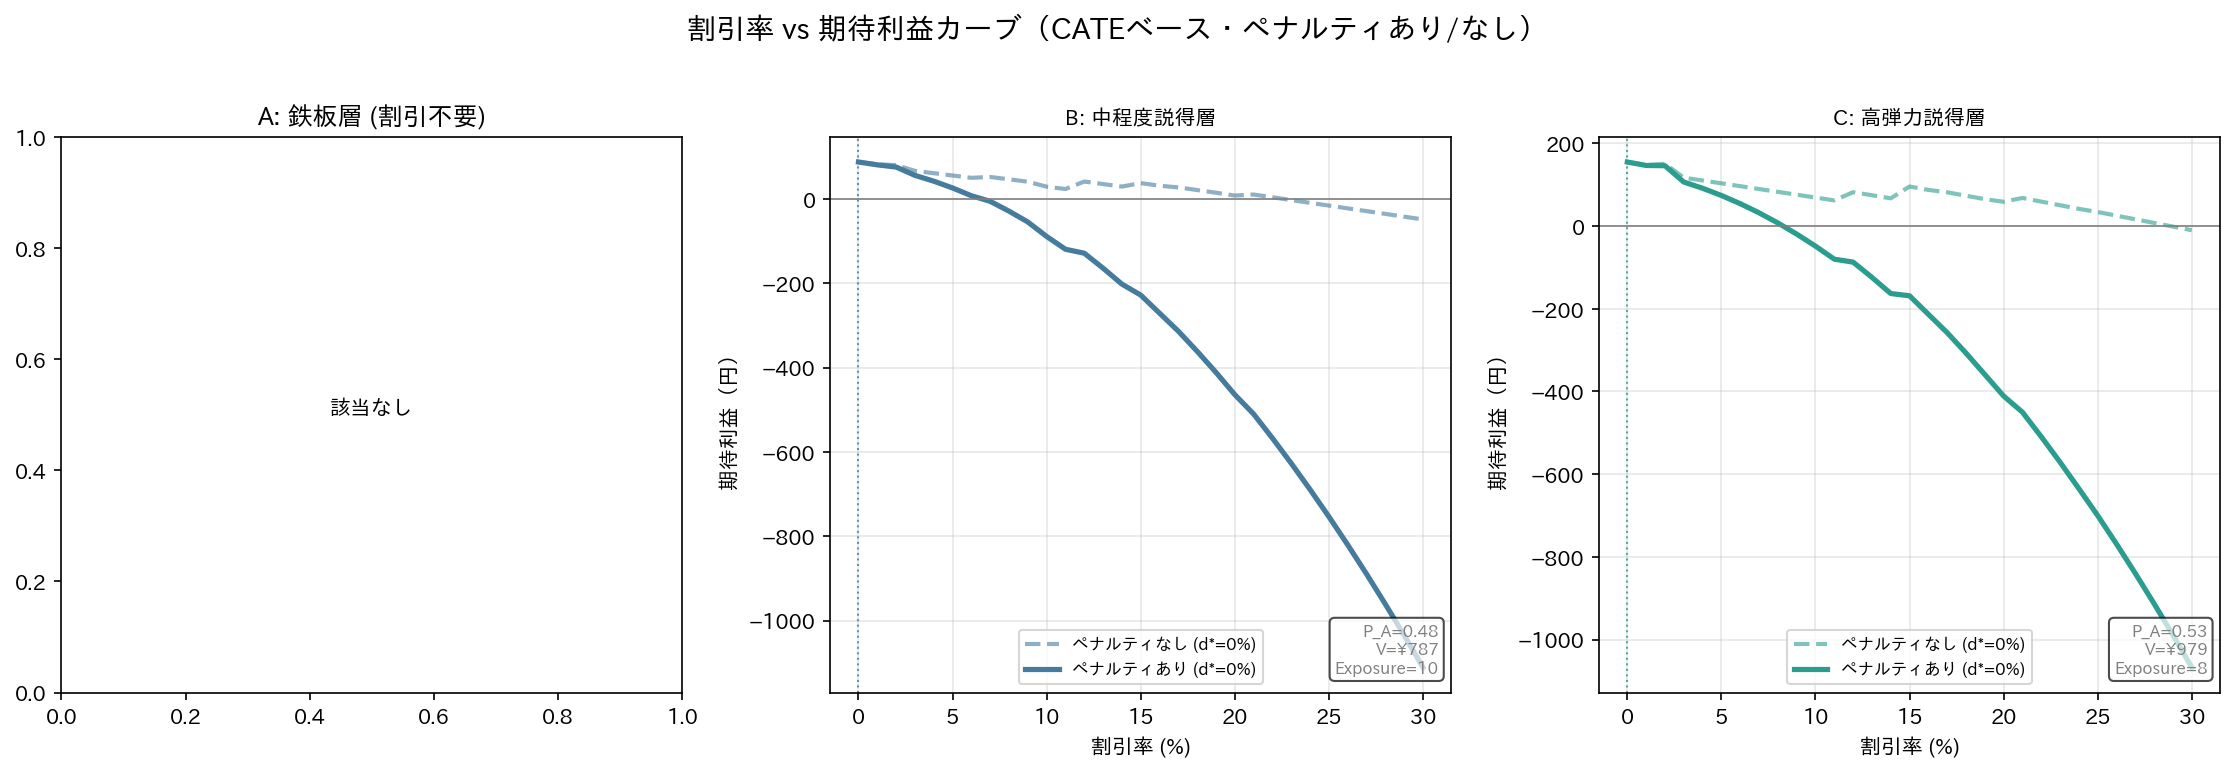

In [29]:
# 割引率 vs 期待利益カーブ（ペナルティあり/なし）
display(Image(filename='outputs/profit_curve_with_penalty.png', width=900))

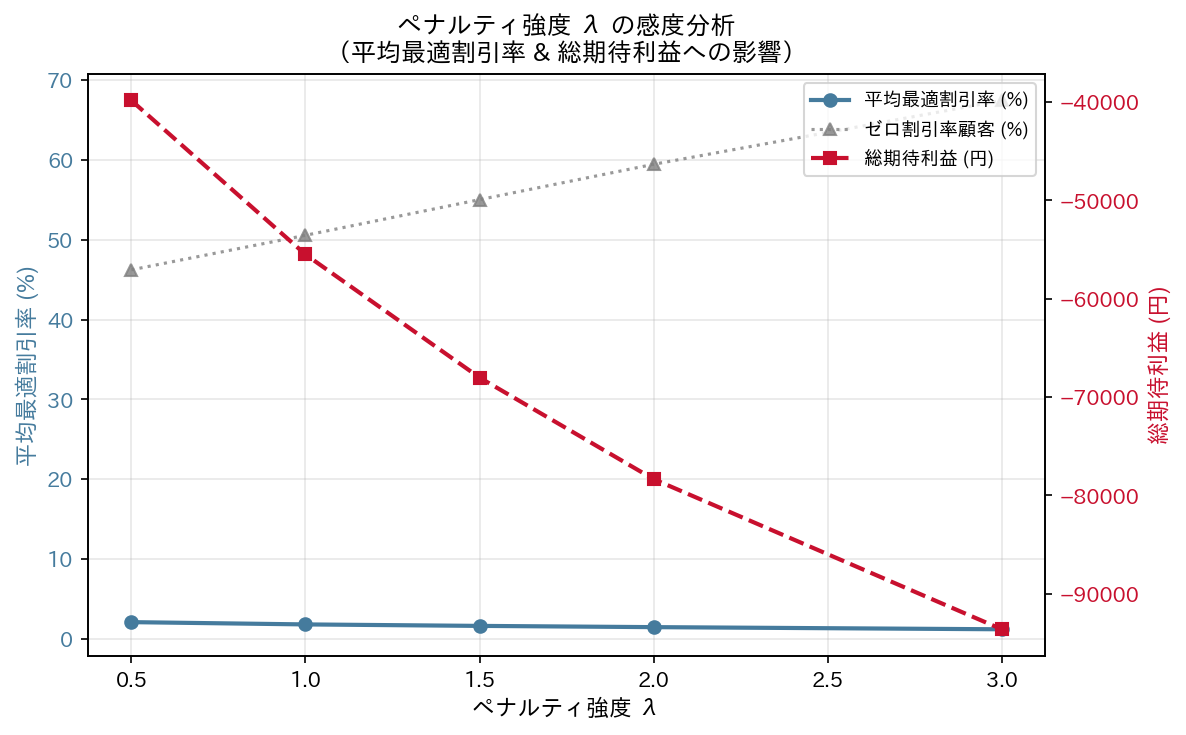

In [30]:
# ペナルティ強度の感度分析
display(Image(filename='outputs/penalty_sensitivity.png', width=650))

---
## 📋 Summary

| 項目 | 内容 |
|------|------|
| 合成顧客数 | 10,000人 |
| セグメント | ファミリー / 単身ヘビー / 学生 / シニア |
| ランク体系 | レギュラー → ブロンズ → シルバー → ゴールド → プラチナ（90日判定） |
| 非金銭インセンティブ | 完全デジタル完結（バッジ・先行情報・デジタルスタンプ） |
| 予測モデル | T-Learner (LightGBM × 2) |
| 目的関数 | CATE × 粗利 − 割引コスト − ペナルティ（λV d² E） |
| 鉄板層判定 | $P_A < 0.10$ → $d^* = 0$ 自動強制 |

### Key Insight

**CATEがゼロの鉄板層では目的関数の第1項もゼロになり、割引コストが必ず利益を上回る。  
T-Learnerを使う必然性が最適化ロジック本体に直結している。**

---

[NOTE記事](https://note.com/tsunoda_data/n/n94bdcf5478db?sub_rt=share_pw)  💻 [GitHub]()
